In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
worker_metadata = pd.read_csv('domain_worker_metadata.csv')

# Định nghĩa các từ khóa để lọc nhóm ngành Khoa học máy tính & IT
it_keywords = ['computer', 'software', 'developer', 'programmer', 'network', 'data', 'information', 'system', 'web']
metadata_it = worker_metadata[worker_metadata['Occupation (O*NET-SOC Title)'].str.lower().fillna('').apply(
    lambda occ: any(keyword in occ for keyword in it_keywords)
)].copy()

# Các cột khảo sát tần suất sử dụng LLM/AI theo tác vụ trong SDLC
usage_cols = {
    'LLM Usage by Type - Coding': 'Lập trình (Coding)',
    'LLM Usage by Type - System Design': 'Thiết kế hệ thống (System Design)',
    'LLM Usage by Type - Data Processing': 'Xử lý dữ liệu (Data Processing)'
}

# Đếm tần suất ứng dụng cho từng tác vụ và chuẩn hóa dữ liệu
frequency_list = []
frequencies_order = ['Daily', 'Weekly', 'Monthly', 'Never']

for col, task_name in usage_cols.items():
    counts = metadata_it[col].value_counts().reindex(frequencies_order, fill_value=0)
    for freq in frequencies_order:
        frequency_list.append({
            'Tác vụ (SDLC)': task_name,
            'Tần suất': freq,
            'Số lượng': counts[freq]
        })

df_usage = pd.DataFrame(frequency_list)

df_usage.to_csv('IT_LLM_Usage_Frequency.csv', index=False, encoding='utf-8-sig')
print("Đã tạo thành công file: IT_LLM_Usage_Frequency.csv")

Đã tạo thành công file: IT_LLM_Usage_Frequency.csv


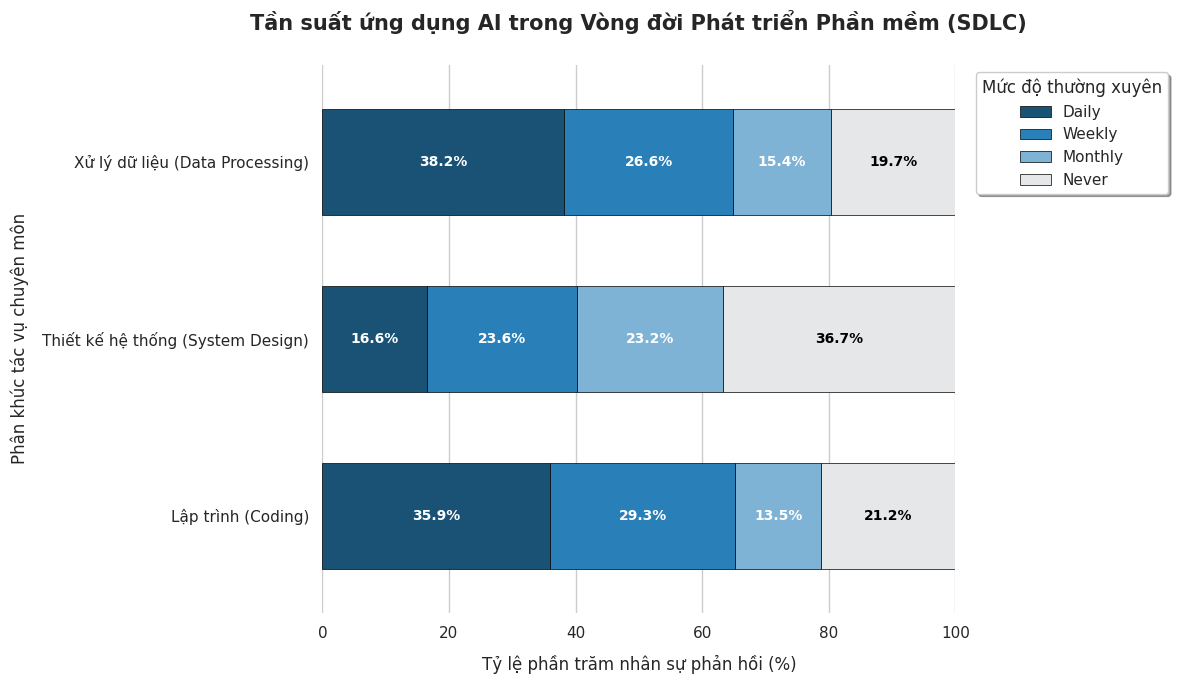

In [10]:
# Chuyển đổi dữ liệu sang dạng bảng chéo (Pivot Table) để tính tỷ lệ phần trăm
pivot_df = df_usage.pivot(index='Tác vụ (SDLC)', columns='Tần suất', values='Số lượng')
# Đảm bảo đúng thứ tự các cột tần suất hiển thị từ thường xuyên đến không sử dụng
pivot_df = pivot_df[frequencies_order]

# Tính toán tỷ lệ % chồng lên nhau (Tổng mỗi hàng = 100%)
pivot_perc = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# =====================================================================
# BƯỚC 3: TRỰC QUAN HÓA (100% Stacked Bar Chart)
# =====================================================================
# Thiết lập cấu hình thẩm mỹ cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans' # Đảm bảo không lỗi hiển thị font hệ thống

# Thiết lập bảng màu chuyên nghiệp (Từ đậm sang nhạt: Hàng ngày -> Không bao giờ)
colors = ['#1a5276', '#2980b9', '#7fb3d5', '#e5e7e9']

fig, ax = plt.subplots(figsize=(12, 7))

# Vẽ biểu đồ thanh ngang chồng 100%
pivot_perc.plot(kind='barh', stacked=True, color=colors, ax=ax, width=0.6, edgecolor='black', linewidth=0.5)

# Bổ sung nhãn dữ liệu số % trực tiếp lên các phân đoạn thanh (Data Labels)
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    if width > 5: # Chỉ hiển thị nhãn nếu phân đoạn đủ rộng (tránh đè chữ)
        ax.text(x + width/2, y + height/2, f'{width:.1f}%',
                va='center', ha='center', color='white' if p.get_facecolor()[0] < 0.6 else 'black',
                fontweight='bold', fontsize=10)

# Cấu trúc trục và tiêu đề biểu đồ theo chuẩn Dashboard
ax.set_title('Tần suất ứng dụng AI trong Vòng đời Phát triển Phần mềm (SDLC)', fontsize=15, fontweight='bold', pad=25)
ax.set_xlabel('Tỷ lệ phần trăm nhân sự phản hồi (%)', fontsize=12, labelpad=10)
ax.set_ylabel('Phân khúc tác vụ chuyên môn', fontsize=12, labelpad=10)
ax.set_xlim(0, 100)

# Tối ưu hóa hiển thị chú thích (Legend)
ax.legend(title='Mức độ thường xuyên', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, shadow=True)

# Làm sạch đường viền thừa
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

In [6]:
desires = pd.read_csv('domain_worker_desires.csv')
experts = pd.read_csv('expert_rated_technological_capability.csv')

# Lọc các ngành nghề (Occupation) thuộc lĩnh vực IT / Khoa học máy tính
it_keywords = ['Computer', 'Software', 'Developer', 'Programmer', 'Network', 'Data', 'Information', 'System', 'Web']
all_occupations = desires['Occupation (O*NET-SOC Title)'].dropna().unique()
it_roles = [role for role in all_occupations if any(kw in role for kw in it_keywords)]

desires_it = desires[desires['Occupation (O*NET-SOC Title)'].isin(it_roles)]
experts_it = experts[experts['Occupation (O*NET-SOC Title)'].isin(it_roles)]

# Tính điểm trung bình (mean) cho từng tác vụ (Task)
avg_desire = desires_it.groupby(['Task ID', 'Task'])['Automation Desire Rating'].mean().reset_index()
avg_capacity = experts_it.groupby('Task ID')['Automation Capacity Rating'].mean().reset_index()

# Hợp nhất dữ liệu dựa trên Task ID
matrix_df = pd.merge(avg_desire, avg_capacity, on='Task ID', how='inner')

In [7]:
output_filename = 'IT_Automation_Priority_Matrix.csv'

matrix_df.to_csv(
    output_filename,
    index=False,
    encoding='utf-8-sig'
)

print(f"Đã gộp và lưu trữ dữ liệu thành công vào file: {output_filename}")

Đã gộp và lưu trữ dữ liệu thành công vào file: IT_Automation_Priority_Matrix.csv


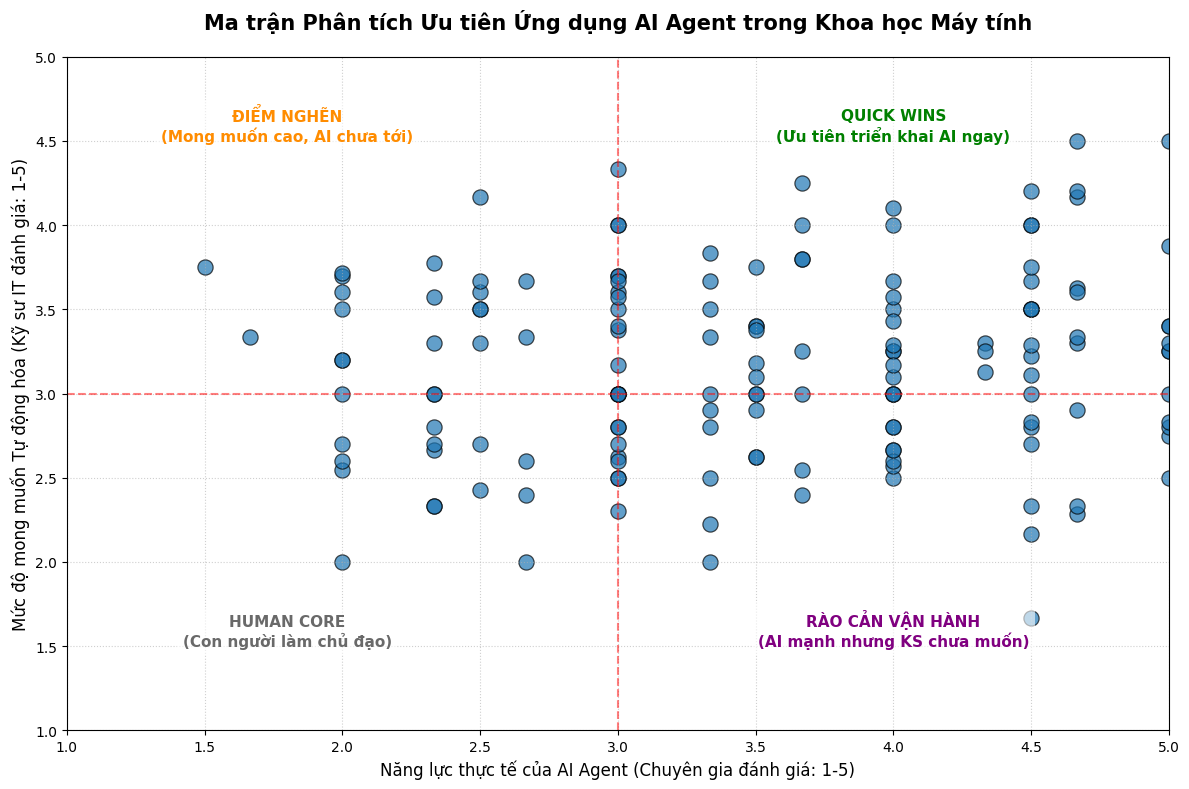

Top các tác vụ ưu tiên tự động hóa bằng AI Agent:
                                                 Task  \
8   Prepare and review operational reports or proj...   
10  Compile and write documentation of program dev...   
11  Write, update, and maintain computer programs ...   
13  Write, analyze, review, and rewrite programs, ...   
15  Investigate whether networks, workstations, th...   

    Automation Capacity Rating  Automation Desire Rating  
8                     3.500000                  3.181818  
10                    4.666667                  3.625000  
11                    4.500000                  3.111111  
13                    3.500000                  3.100000  
15                    5.000000                  3.400000  


In [8]:
plt.figure(figsize=(12, 8))

# Vẽ biểu đồ phân tán
sns.scatterplot(
    data=matrix_df,
    x='Automation Capacity Rating',
    y='Automation Desire Rating',
    s=120, # Kích thước điểm
    color='#1f77b4',
    edgecolor='black',
    alpha=0.7
)

# Chia 4 góc phần tư (Giả định mốc 3.0 là mức trung bình trên thang 1-5)
plt.axvline(x=3.0, color='red', linestyle='--', alpha=0.5)
plt.axhline(y=3.0, color='red', linestyle='--', alpha=0.5)

# Bổ sung Text chú thích cho các góc phần tư để làm nổi bật Business Value
plt.text(4.0, 4.5, 'QUICK WINS\n(Ưu tiên triển khai AI ngay)',
         fontsize=11, color='green', fontweight='bold', ha='center', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.text(1.8, 4.5, 'ĐIỂM NGHẼN\n(Mong muốn cao, AI chưa tới)',
         fontsize=11, color='darkorange', fontweight='bold', ha='center', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.text(4.0, 1.5, 'RÀO CẢN VẬN HÀNH\n(AI mạnh nhưng KS chưa muốn)',
         fontsize=11, color='purple', fontweight='bold', ha='center', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.text(1.8, 1.5, 'HUMAN CORE\n(Con người làm chủ đạo)',
         fontsize=11, color='dimgray', fontweight='bold', ha='center', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# Trang trí biểu đồ
plt.title('Ma trận Phân tích Ưu tiên Ứng dụng AI Agent trong Khoa học Máy tính', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Năng lực thực tế của AI Agent (Chuyên gia đánh giá: 1-5)', fontsize=12)
plt.ylabel('Mức độ mong muốn Tự động hóa (Kỹ sư IT đánh giá: 1-5)', fontsize=12)
plt.xlim(1, 5)
plt.ylim(1, 5)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# (Tùy chọn) In ra top 5 tác vụ "Quick Wins" để làm dẫn chứng cho bài thi
quick_wins = matrix_df[(matrix_df['Automation Capacity Rating'] > 3.0) & (matrix_df['Automation Desire Rating'] > 3.0)]
print("Top các tác vụ ưu tiên tự động hóa bằng AI Agent:")
print(quick_wins[['Task', 'Automation Capacity Rating', 'Automation Desire Rating']].head())